**14/08/2026** -- Supplementary figure S6: Relationship between deprivation and fire PM2.5 exposure

Using 2000-2022 data

In [1]:
library(dplyr)
library(readr)
library(ggplot2)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [7]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/pca.R"))
source(file.path(root, "src/deprivation_pm_bhm/data_prep.R"))
source(file.path(root, "src/utils/utils.R"))

In [3]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_2000_2023.csv")

In [25]:
# Load data and estimate PC1 deprivation index
df <- read_csv(DATA_PATH) |> 
    filter(year <= 2022) |> 
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars
    ungroup()

df <- project_indicators(
    df, 
    list(edu_mean_years     = 2017,
         imp_san_access_pct = 2017,
         stunting_pct_u5    = 2017
    )
)

# Do PCA
pca_res <- compute_pca(
    df,
    method          = "ppca",
    se_indicators   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc",
                        "child_dep_pct", "stunting_pct_u5"),
    n_pcs           = 5,
    scale           = TRUE,
    centre          = TRUE,
    seed            = 42,
    positive_vars   = c("child_dep_pct", "stunting_pct_u5"),
    negative_vars   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc")
)

# Join PCs back onto df (helper funct)
df  <- prepare_analysis_data(df, 
                             pca_res$data, 
                             outcome = "fire_PM25_hu", # arbitrary, won't be used
                             scale_y = FALSE,
                             scale_PC1 = TRUE)

Rows: 994412 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (63): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Projecting edu_mean_years forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0227167 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


[1] "Projecting imp_san_access_pct forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00349425 (tol = 0.002, component 1)”


[1] "Projecting stunting_pct_u5 forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0278442 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”
Warning message in pcaMethods::ppca(X, nPcs = n_pcs, seed = seed):
“stopped after max iterations, but rel_ch was > threshold”


In [26]:
df <- df |> 
    mutate(region = recode(region, "Middle Africa" = "Central Africa"))

In [27]:
# Function to make the geofacet hexbin plot
geopanel_hexbin <- function(
    plot_data, global_color = "#01665e", alpha_min = 0.2,
    y_var = "fire_PM25_hu", x_var = "PC1",
    global_subplot_title = NULL, bins_global = 60, bins_country = 20,
    include_axes_legend_grob = TRUE
    ) {    
    # Create custom Africa grid to arrange the mini scatters -- doesn't include Mauritius or Seychelles
    africa_grid <- data.frame(
        name = c("Algeria", "Egypt", "Libya", "Morocco", "Tunisia", "Gambia", "Mali", "Niger", "Sudan", "Mauritania", "Senegal", "Burkina Faso", "Chad", "Eritrea", "Sierra Leone", "South Sudan", "Guinea", "Guinea-Bissau", "Djibouti", "Central African Republic", "Ethiopia", "Ghana", "Somalia", "Togo", "Nigeria", "Liberia", "Benin", "Cabo Verde", "Congo (Democratic Republic of the)", "Kenya", "Uganda", "Côte d'Ivoire", "Cameroon", "Burundi", "Equatorial Guinea", "Rwanda", "Tanzania", "Congo", "Sao Tome and Principe", "Malawi", "Mozambique", "Gabon", "Angola", "Zambia", "Botswana", "Comoros", "Zimbabwe", "Namibia", "Lesotho", "Madagascar", "Swaziland", "South Africa"),
        ISO_A3 = c("DZA", "EGY", "LBY", "MAR", "TUN", "GMB", "MLI", "NER", "SDN", "MRT", "SEN", "BFA", "TCD", "ERI", "SLE", "SSD", "GIN", "GNB", "DJI", "CAF", "ETH", "GHA", "SOM", "TGO", "NGA", "LBR", "BEN", "CPV", "COD", "KEN", "UGA", "CIV", "CMR", "BDI", "GNQ", "RWA", "TZA", "COG", "STP", "MWI", "MOZ", "GAB", "AGO", "ZMB", "BWA", "COM", "ZWE", "NAM", "LSO", "MDG", "SWZ", "ZAF"),
        col = c(4, 7, 6, 3, 5, 2, 5, 6, 7, 4, 3, 5, 6, 8, 4, 7, 3, 2, 8, 6, 7, 3, 9, 4, 5, 2, 4, 1, 6, 8, 7, 3, 5, 6, 4, 7, 8, 5, 2, 7, 8, 4, 5, 6, 6, 9, 7, 5, 6, 10, 7, 7),
        row = c(1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 10),
        stringsAsFactors = FALSE
    )
    
    # Some hacking of the grid
    africa_grid <- africa_grid %>%
        mutate(
            x = col + 2,  # 'nudge' right by 2 units
            y = max(row) - row  # invert rows so 'row 1' becomes highest on y-axis
        ) #%>% 
        # filter(!ISO_A3 %in% c("CPV", "STP")) # remove Cabo Verde, São Tomé and Príncipe
    
    # (HARDCODED) Limits of x and y axes for mini panels
    ymin <- -1 # (for some padding below y=0 tick)  #0
    ymax <- 50  # plot_data %>% filter(complete.cases(PC1, fire_PM25)) %>% select(fire_PM25) %>% max() ~= 30.47 # hu (2022): 87.75
    xmin <- -3.1  # plot_data %>% filter(complete.cases(PC1, fire_PM25)) %>% select(PC1) %>% min() ~= -3.01     # 2000-2022 impute: -3.12
    xmax <- 2.2  # plot_data %>% filter(complete.cases(PC1, fire_PM25)) %>% select(PC1) %>% max() ~= 2.15       # 2000-2022 impute: 2.16

    # Regions colour palette (Set1 -- https://emilhvitfeldt.github.io/r-color-palettes/discrete/RColorBrewer/Set1/index.html)
    region_colours <- c(
        "Northern Africa" = "#E41A1CFF",
        "Western Africa" = "#377EB8FF",
        "Central Africa" = "#4DAF4AFF",
        "Eastern Africa" = "#984EA3FF",
        "Southern Africa" = "#FF7F00FF"
    )
    
    # Create plot for the axes 'legend' -- an overall scatter including all points in Africa, coloured by U/R
    axis_ovr <- plot_data
    axis_ovr_plot <- ggplot(axis_ovr, 
                            aes(x = !!sym(x_var), y = !!sym(y_var), 
                                color = region,
                                fill = region)
                           ) +
        geom_hex(bins = bins_global, aes(fill = after_stat(count)), color = NA) +  # no border lines
        geom_smooth( # regression line
                method = "lm", se = TRUE, 
                level=0.95, size = 0.6,
                color = global_color, fill = global_color
        ) +
        scale_fill_gradient(
            low = scales::alpha(global_color, alpha_min),   # light fill for low count
            high = global_color,                     # full region color for high count
            # guide = "none"
            name = "Number of\nobservations",
            labels = scales::label_comma(),
            guide = guide_colourbar(
                barwidth = unit(40, "mm"),
                barheight = unit(4, "mm")
            )
        ) +
        labs(
            x = "Increasing deprivation ⟶", #\n(SD from Africa average)",
            y = expression(paste("Fire ", PM[2.5], " (", mu, "g/m"^3, ")"))
        ) +
        scale_x_continuous(
            limits = c(xmin, xmax),
            expand = expansion(mult = c(0.06, 0))
        ) +
        scale_y_continuous(
            limits = c(ymin, ymax),
            expand = expansion(mult = c(0.04, 0))
        ) +
        coord_cartesian(clip = 'off') +
        theme_minimal(base_size = 10) +
        ggtitle(global_subplot_title) +
        theme(
            legend.position = "bottom",
            legend.text = element_text(size = 11),
            legend.title = element_text(size = 12),
            panel.grid = element_blank(),
            plot.title = element_text(size = 14),
            axis.title = element_text(size = 13),
            axis.text = element_text(size = 12),
            # plot.margin = margin(5, 5, 5, 5),
            axis.line.x = element_line(linewidth = 0.8),
            axis.line.y = element_line(linewidth = 0.8),
            axis.ticks = element_line(linewidth = 0.8),
            axis.ticks.length.y = unit(1.2, "mm"),
            axis.ticks.length.x = unit(1.2, "mm"),
        )
    
    # Convert axis plot to grob
    axis_legend_grob <- ggplotGrob(axis_ovr_plot)
    
    # Build inset plots (grobs -- mini panel scatters)
    insets <- purrr::pmap(
        list(africa_grid$ISO_A3, africa_grid$x, africa_grid$y),
        function(iso, x, y) {
            dat <- plot_data %>% filter(ISO_A3 == iso)
            
            if (nrow(dat) == 0) return(NULL)
    
            grob <- ggplotGrob(
                ggplot(dat, aes(x = !!sym(x_var), y = !!sym(y_var), color = region, fill = region)) +
                    geom_hex(bins = bins_country, aes(fill = after_stat(count)), color = NA) +  # no border lines
                    geom_smooth( # regression line
                        method = "lm", se = TRUE, 
                        level = 0.95, size = 0.6,
                        color = region_colours[[dat$region[1]]],
                        fill = region_colours[[dat$region[1]]]
                    ) +
                    scale_fill_gradient(
                        low = scales::alpha(region_colours[[dat$region[1]]], alpha_min),   # light fill for low count
                        high = region_colours[[dat$region[1]]],                     # full region color for high count
                        guide = "none"
                    ) +                
                    theme_void() +
                    theme(
                        axis.line.x = element_line(linewidth = 0.8),
                        axis.line.y = element_line(linewidth = 0.8),
                        axis.ticks = element_line(linewidth = 0.8),
                        axis.ticks.length.y = unit(1.2, "mm"),
                        axis.ticks.length.x = unit(1.2, "mm"),
                    ) +
                    theme(legend.position = "none") +
                    scale_x_continuous(limits = c(xmin, xmax), expand = expansion(mult = c(.075, 0))) + # 7.5% padding to left  # for no padding use: c(0,0) 
                    scale_y_continuous(limits = c(ymin, ymax), expand = expansion(mult = c(.075, 0))) # 7.5% padding below (so that scatter points with 0 PM2.5 don't sit on x-axis)
            )
            
            tibble(iso = iso, x = x, y = y, grob = list(grob))
        }
    ) %>% bind_rows()
    
    # Side length of inset box
    a <- 0.4
    
    # Create final plot with insets
    p <- ggplot() +
        coord_fixed() +
        theme_void() +
        purrr::pmap(
            list(insets$x, insets$y, insets$grob),
            ~ annotation_custom(..3, xmin = ..1 - a, xmax = ..1 + a, ymin = ..2 - a, ymax = ..2 + a) #..3 means third function argument
        ) +
        geom_text(data = africa_grid, 
                  aes(x = x, y = y + a * 1.1, label = ISO_A3), # place the text just above top of inset box (1.1 * box height)
                  size = 4.25)#3) 
    
    # Add axes legend
    if (include_axes_legend_grob) {
        p <- p + annotation_custom(
            grob = axis_legend_grob,
            # xmin = 4, xmax = 6.5,
            # ymin = -0.5, ymax = 2
            # xmin = 3.9, xmax = 6.4,
            # ymin = -0.7, ymax = 2
            # xmin = 3.8, xmax = 6.3,
            # ymin = -0.7, ymax = 2
            # ## updates 19/01: including CPV, STP
            # xmin = 3.4, xmax = 5.9,
            # ymin = -0.8, ymax = 2
            ## updates 05/06: vertical layout w/ colorbar
            xmin = 2, xmax = 5,
            ymin = -0.7, ymax = 3.1
        )
    }
    
    # Margin to avoid edges being clipped
    p <- p + theme(plot.margin = margin(t = 5, r = 10, b = 5, l = 10))  # top, right, bottom, left (in pts)
    
    # Return the plot
    p
}

In [28]:
suppressWarnings({

plot_rural <- geopanel_hexbin(
    df[df$urban_rural_cat == "rural",] %>% filter(!is.na(PC1)),
    global_color = "#01665e",  # teal
    alpha_min = 0.15,
    global_subplot_title = "All rural areas"
) + 
    ggtitle("Rural") + 
    theme(plot.title = element_text(size = 16, #14, 
                                    face = "bold",
                                    margin = margin(b = -20)))

plot_urban <- geopanel_hexbin(
    df[df$urban_rural_cat == "urban",] %>% 
        filter(!is.na(PC1)) %>%
        bind_rows(tibble(  # Hacky -- create NA urban rows for SSD, GNQ, COM, LSO so that empty axes appear (rather than completely blank panel)
            ISO_A3 = c("SSD", "GNQ", "COM", "LSO"),
            region = c("Eastern Africa", "Central Africa", "Eastern Africa", "Southern Africa"),
            fire_PM25 = NA, PC1 = NA, urban_rural_cat = "urban"
        )),
    global_color = "#8c510a",  # brown
    alpha_min = 0.15,
    global_subplot_title = "All urban areas"
) + 
    ggtitle("Urban") +
    theme(plot.title = element_text(size = 16, #14, 
                                    face = "bold",
                                    margin = margin(b = -20)))

}) # end suppressWarnings

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [29]:
# Regions colour palette (Set1 -- https://emilhvitfeldt.github.io/r-color-palettes/discrete/RColorBrewer/Set1/index.html)
region_colours <- c(
    "Northern Africa" = "#E41A1CFF",
    "Western Africa" = "#377EB8FF",
    "Central Africa" = "#4DAF4AFF",
    "Eastern Africa" = "#984EA3FF",
    "Southern Africa" = "#FF7F00FF"
)

# Create dummy plot for the region colour legend
region_dummy_plot <- ggplot(
    data.frame( # create toy data.frame to extract region labels
        Region = factor(names(region_colours), levels = names(region_colours)), 
        x = 1, y = 1
    ),
    aes(x, y, color = Region)
) +
    geom_line() +
    scale_color_manual(values = region_colours) +
    theme_void() +
    theme(
        legend.position = "bottom", 
        legend.title = element_blank(),
        legend.text = element_text(size = 14), #12),
        legend.key.spacing.x = unit(15, "pt") # horizontal spacing between label and keys
    ) +
    guides(color = guide_legend(nrow = 1, byrow = TRUE))


# Extract the region colour legend as a grob
region_legend <- ggpubr::get_legend(region_dummy_plot)

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


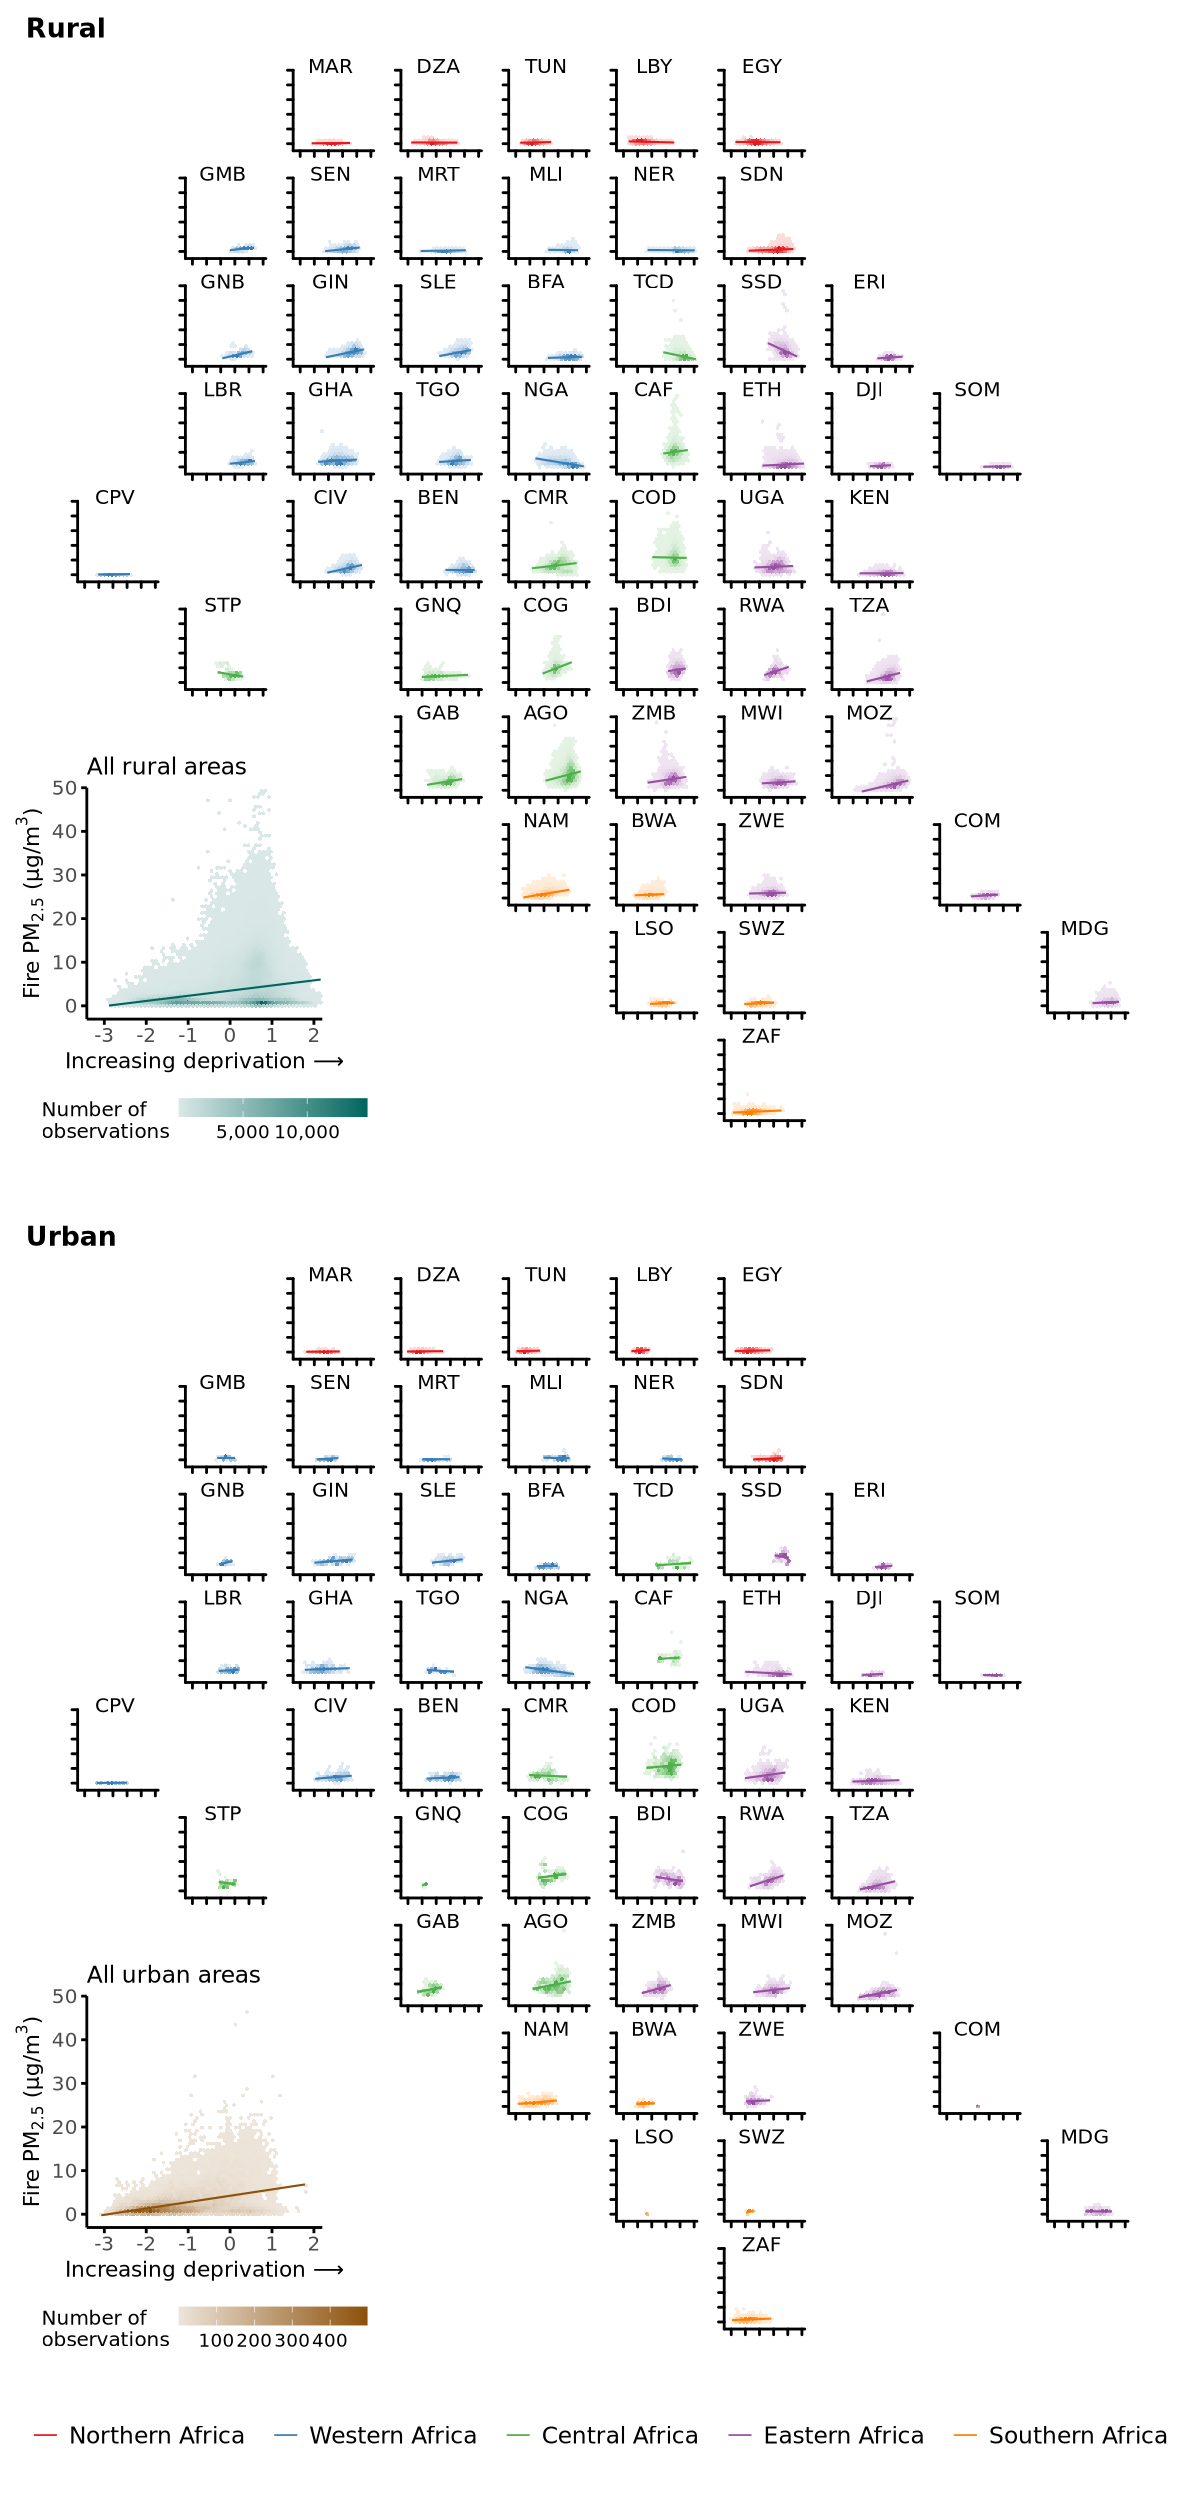

In [30]:
options(repr.plot.width = 10, repr.plot.height = 21, quality = 450)
geofacet_patchwork_ur <- (
    plot_rural / plot_spacer() / plot_urban / plot_spacer()   / region_legend
) + plot_layout(heights = c(8, 0.8, 8, 0.3, 1))  # make legend row shorter

suppressWarnings({
    print(geofacet_patchwork_ur)
})

In [ ]:
ggsave(
    filename = file.path(root, "paper_results/figures/supplementary_fig_S6.png"),   #supplementary_fig_S6_with_slopes.png
    dpi = 450,
    width = 10,
    height = 21,
    bg = "white"
)